In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('FuelConsumptionCo2.csv')

In [3]:
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [5]:
# Select features and target variable
X = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
X.head()


,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


array([[<Axes: title={'center': 'ENGINESIZE'}>,
        <Axes: title={'center': 'CYLINDERS'}>],
       [<Axes: title={'center': 'FUELCONSUMPTION_COMB'}>,
        <Axes: title={'center': 'CO2EMISSIONS'}>]], dtype=object)

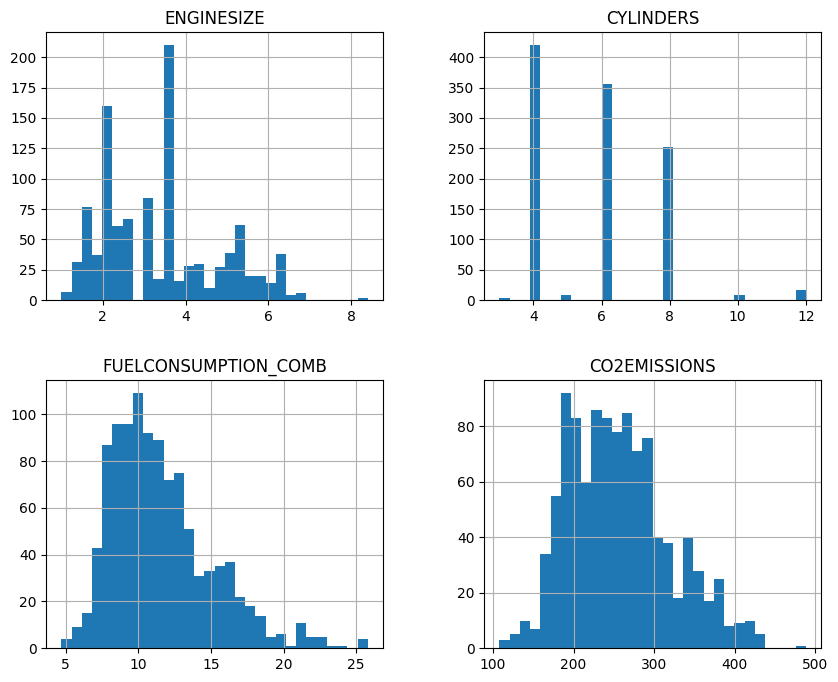

In [ ]:
# Now let's visualize these features using histograms to understand their distributions.
X.hist(bins=30, figsize=(10, 8))


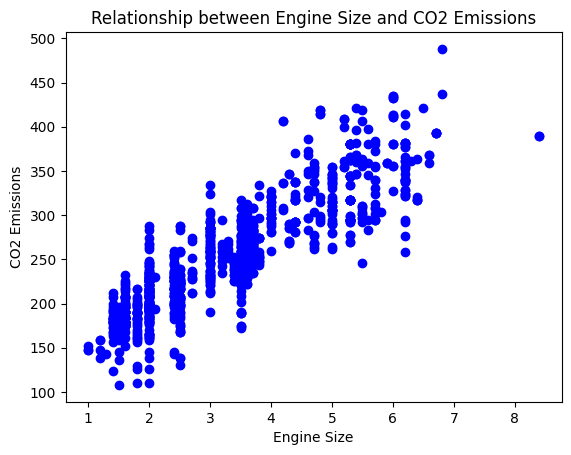

In [10]:
# Now let's visualize the relationship between the features and the target variable (CO2EMISSIONS) using scatter plots.
plt.scatter(X['ENGINESIZE'], X['CO2EMISSIONS'], color='blue')
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')
plt.title('Relationship between Engine Size and CO2 Emissions')
plt.show()

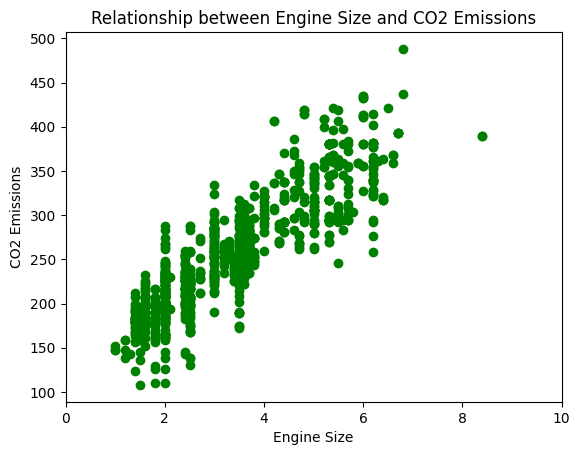

In [15]:
plt.scatter(X['ENGINESIZE'], X['CO2EMISSIONS'], color='green')
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')
plt.title('Relationship between Engine Size and CO2 Emissions')
plt.xlim(0, 10)
plt.show()

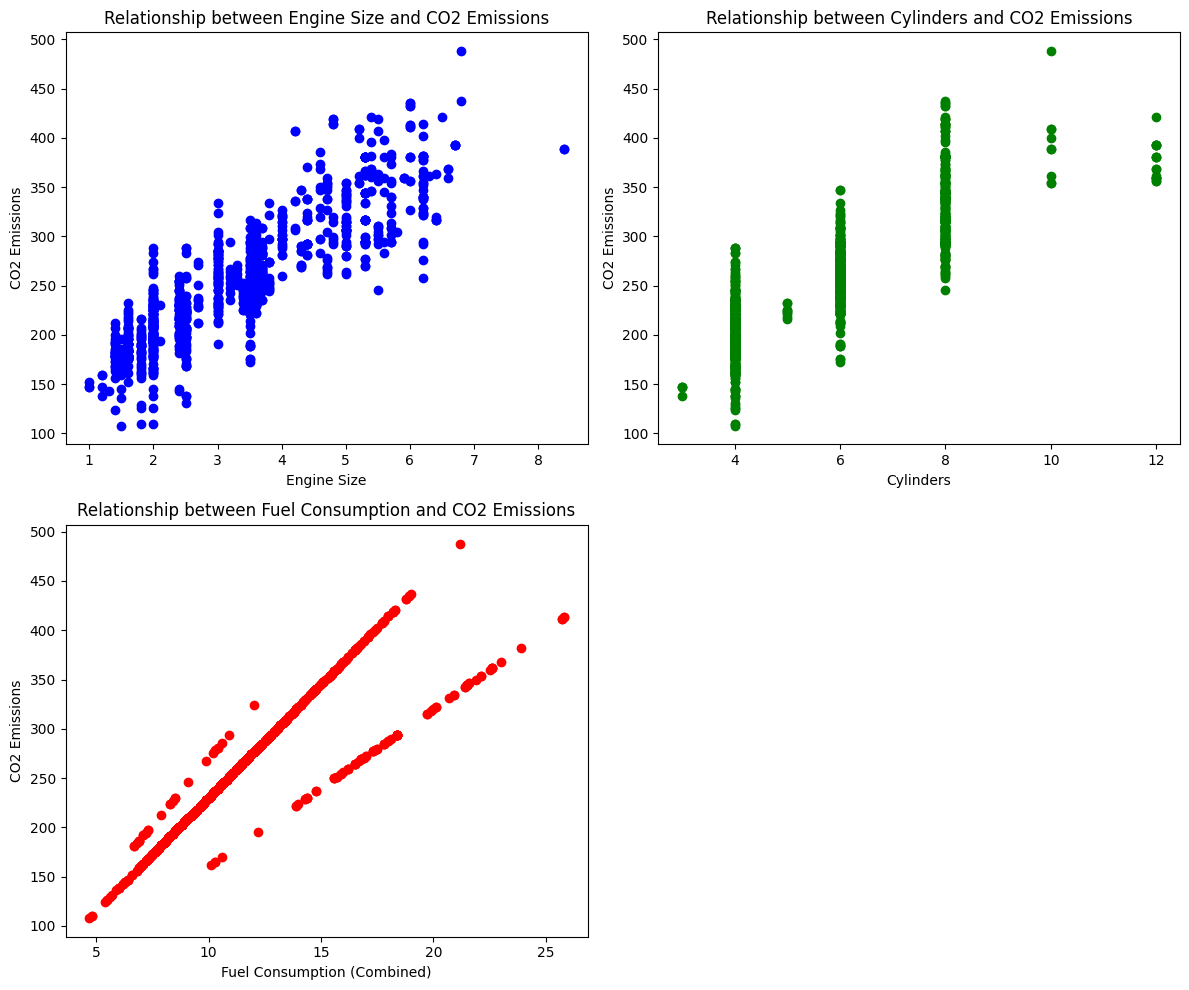

In [11]:
# Now let's visualize the relationship between the features and the target variable (CO2EMISSIONS) using scatter plots.
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.scatter(X['ENGINESIZE'], X['CO2EMISSIONS'], color='blue')
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')
plt.title('Relationship between Engine Size and CO2 Emissions')
plt.subplot(2, 2, 2)
plt.scatter(X['CYLINDERS'], X['CO2EMISSIONS'], color='green')
plt.xlabel('Cylinders')
plt.ylabel('CO2 Emissions')
plt.title('Relationship between Cylinders and CO2 Emissions')
plt.subplot(2, 2, 3)
plt.scatter(X['FUELCONSUMPTION_COMB'], X['CO2EMISSIONS'], color='red')
plt.xlabel('Fuel Consumption (Combined)')
plt.ylabel('CO2 Emissions')
plt.title('Relationship between Fuel Consumption and CO2 Emissions')
plt.tight_layout()


In [21]:
# Now take input and output variables
X1 = df[['ENGINESIZE']]
y1 = df[['CO2EMISSIONS']]


In [22]:
from sklearn.model_selection import train_test_split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)


In [23]:
type(X1_train), type(X1_test), type(y1_train), type(y1_test)


(pandas.DataFrame, pandas.DataFrame, pandas.DataFrame, pandas.DataFrame)

In [24]:
np.shape(X1_train), np.shape(X1_test), np.shape(y1_train), np.shape(y1_test)

((853, 1), (214, 1), (853, 1), (214, 1))

In [30]:
# Simple Linear Regression Model

from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X1_train, y1_train)

print("Coefficients: ", LR.coef_)
print("Intercept: ", LR.intercept_)


Coefficients:  [[38.99297872]]
Intercept:  [126.28970217]


Text(0, 0.5, 'CO2 Emissions')

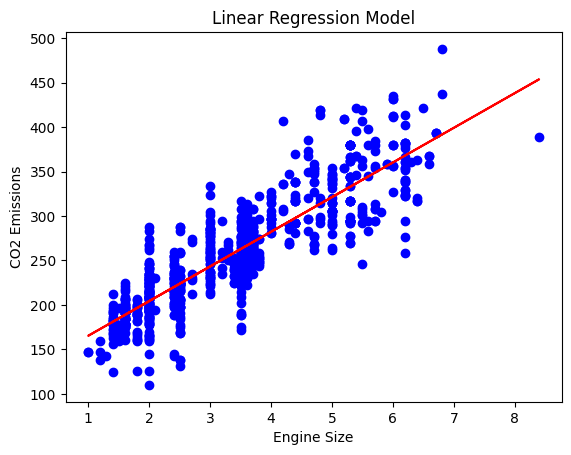

In [36]:
# Visulaize the Output of the model

plt.scatter(X1_train, y1_train, color='blue')
plt.plot(X1_train, LR.predict(X1_train), color='red')
# plt.plot(X1_train, LR.intercept_ + LR.coef_ * X1_train, color='red')
# plt.plot(X1_train, LR.coef_ * X1_train + LR.intercept_, '-r')

plt.title('Linear Regression Model')


plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')

In [37]:
# Model Evoluation using MAE,MSE, RMSE, R2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y1_pred = LR.predict(X1_test)

mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y1_test, y1_pred)

print("Mean Absolute Error (MAE): ", mae)
print("Mean Squared Error (MSE): ", mse)
print("Root Mean Squared Error (RMSE): ", rmse)
print("R-squared (R2): ", r2)

Mean Absolute Error (MAE):  24.09725741170784
Mean Squared Error (MSE):  985.9381692274999
Root Mean Squared Error (RMSE):  31.399652374309813
R-squared (R2):  0.7615595731934373


Let's see the evaluation metrics if you train a regression model using the FUELCONSUMPTION_COMB feature.

2. Select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets.
Use the same random state as previously so you can make an objective comparison to the previous training result.

In [40]:
# Fuel Comsumption feature
X2 = df[['FUELCONSUMPTION_COMB']]

X2_train, X2_test, y1_train, y1_test = train_test_split(X2, y1, test_size=0.2, random_state=42)

LR.fit(X2_train, y1_train)

print("Coefficients: ", LR.coef_)
print("Intercept: ", LR.intercept_)



Coefficients:  [[16.18090078]]
Intercept:  [69.10302618]


Text(0, 0.5, 'CO2 Emissions')

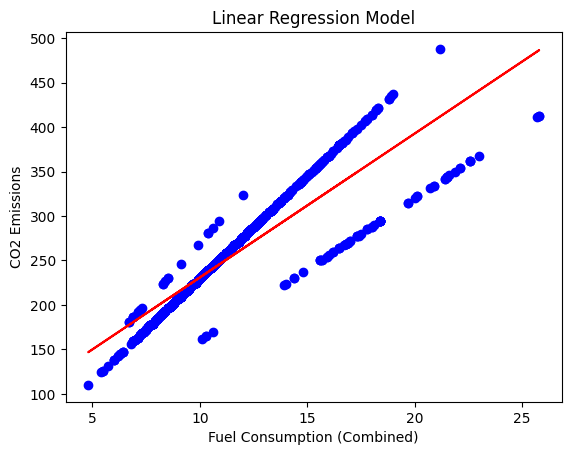

In [41]:
plt.scatter(X2_train, y1_train, color='blue')
plt.plot(X2_train, LR.predict(X2_train), color='red')

plt.title('Linear Regression Model')
plt.xlabel('Fuel Consumption (Combined)')
plt.ylabel('CO2 Emissions')

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y1_pred = LR.predict(X2_test)

print("Mean Absolute Error: ", mean_absolute_error(y1_test, y1_pred))
print("Mean Squared Error: ", mean_squared_error(y1_test, y1_pred))
print("R2 Score: ", r2_score(y1_test, y1_pred))

Mean Absolute Error:  20.441911472549585
Mean Squared Error:  797.4346310097205
R2 Score:  0.8071474868274242
